## Coursework – Data Classification (60 marks)

This coursework counts for 60% of the overall assessment for this module. 
In this assessment, you will classify vehicle silhouettes into one of four vehicle types using the UCI Statlog (Vehicle Silhouettes) dataset. You will explore the dataset, preprocess the data, implement various classification algorithms, and evaluate their performance.
The dataset includes 846 instances, each described by 18 numerical features related to the vehicle's silhouette shape. The goal is to classify the silhouettes into one of the following four categories:

1. Bus
2. Opel
3. Saab
4. Van

**Submission Requirements:**
You need to submit two files to the link “Assignment>>Coursework assignment>>Coursework submission link. The two files are:

1.	The provided Jupyter Notebook file, completed in .ipynb format.
2.	The provided Jupyter Notebook file, completed in .html format.
  
Use File -> download as... -> HTML/IPYNB in the Jupyter Notebook menu bar to save this notebook in html/ipynb format.
The programming language you should use to complete this assessment is Python (in version 3 and above). You can use any Python library or package. All Python skills needed to do this assessment have been covered in the practical sessions –practical notes are available on Canvas.

**Feedback:**
A score and the filled-in individual Rubric with a general comment. 


### Task 1: Data pre-processing and data exploration (12 marks)


#### a)	Load the dataset as a pandas data frame (2 marks), and explore the features  (4 marks).

In [2]:
import pandas as pd #Import pandas library
url = "Statlog_dataset.csv" #Name of file
data = pd.read_csv(url) #Load the dataset
data.head() #Show the first few rows of the data

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  scaled_radius_of_gyr

In [6]:
data["class"].unique() #Classes are objects

array(['van', 'car', 'bus'], dtype=object)

In [8]:
#Label Encoding to convert categorical data to numerical data (object -> integer)
from sklearn.preprocessing import LabelEncoder #Import LabelEncoder function from sklearn.preprocessing module

LabelEncoder = LabelEncoder() #Initializing Label Encoder model

data["class"] = LabelEncoder.fit_transform(data["class"]) #Apply Label Encoder to the class column in dataset

In [9]:
data.info() #Classes are now integers

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  scaled_radius_of_gyr

In [10]:
data["class"].unique() #Bus, Car, Van -> 0, 1, 2 respectively

array([2, 1, 0])

#### b)	Handle Missing values (if any)(2 marks).


In [15]:
data.isnull().sum() #Checking for missing values

compactness                    0
circularity                    5
distance_circularity           4
radius_ratio                   6
pr.axis_aspect_ratio           2
max.length_aspect_ratio        0
scatter_ratio                  1
elongatedness                  1
pr.axis_rectangularity         3
max.length_rectangularity      0
scaled_variance                3
scaled_variance.1              2
scaled_radius_of_gyration      2
scaled_radius_of_gyration.1    4
skewness_about                 6
skewness_about.1               1
skewness_about.2               1
hollows_ratio                  0
class                          0
dtype: int64

In [17]:
data = data.dropna() #Dropping missing values due to an insignificant amount of NaN compared to total ~846 entries

In [19]:
data.isnull().sum() #No more missing values

compactness                    0
circularity                    0
distance_circularity           0
radius_ratio                   0
pr.axis_aspect_ratio           0
max.length_aspect_ratio        0
scatter_ratio                  0
elongatedness                  0
pr.axis_rectangularity         0
max.length_rectangularity      0
scaled_variance                0
scaled_variance.1              0
scaled_radius_of_gyration      0
scaled_radius_of_gyration.1    0
skewness_about                 0
skewness_about.1               0
skewness_about.2               0
hollows_ratio                  0
class                          0
dtype: int64

#### c)	Divide the dataset into a training set (60%) , a validation set (20%) and a testing set (20%) (4 mark).

In [22]:
from sklearn.model_selection import train_test_split #Import the train_test_split function from sklearn.model_selection module

In [24]:
X = data.drop(columns=["class"]) #Assign feature columns to X
Y = data["class"] #Assign class column to Y


In [26]:
X.shape #dimensions of X - 18 features, 813 data per feature

(813, 18)

In [28]:
Y.shape #dimensions of Y

(813,)

In [30]:
#Split the data to 60% Training, 20% Testing, 20%Validation
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size = 0.4, random_state=42) #60% Training, 40% Temp
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size = 0.5, random_state=42) #Temp - 50% Validation, 50% Testing


### Task 2: Do a principal component analysis (18 marks)



 
#### a)	Standardise the training dataset and perform a PCA analysis on the training data set. Explain your findings in a markdown cell (6 marks).


In [34]:
import numpy as np #Imports numpy library
from sklearn import preprocessing #Imports preprocessing module from sklearn
from sklearn.decomposition import PCA #Imports PCA function from sklearn.decomposition module

#Standardising the training, validation and testing dataset
scaler = preprocessing.StandardScaler() #Initailizing a StandardScaler object

X_train_scaled = scaler.fit_transform(X_train) #Standardize training data

X_val_scaled = scaler.transform(X_val) #Standardize validation data

X_test_scaled = scaler.transform(X_test) #Standardize testing data


In [36]:
pca = PCA(0.9) #Initializing PCA model with 90% variance
pca.fit(X_train_scaled) #Fit the model with training data

PCA(n_components=0.9)

In [40]:
X_train_scores = pca.transform(X_train_scaled) #Perform PCA on training dataset
train_scores_df = pd.DataFrame(X_train_scores[:,:3], columns=['PC1', 'PC2', 'PC3']) 
#Create a dataframe including first three principal componenets for readability
train_scores_df

,PC1,PC2,PC3
0,5.065309,1.191053,-0.005658
1,4.441810,-0.129317,-0.092712
2,4.434993,-0.800743,-0.845031
3,0.396718,1.611450,0.374795
4,-1.765913,2.752162,-0.036320
...,...,...,...
482,-1.955747,-3.752513,-0.670928
483,0.170909,0.299579,0.297870
484,-3.266570,1.514308,-0.586166
485,-1.794894,-1.827240,0.867204


In [42]:
Y_label = [] #Empty array to append class labels to

#Decode 0,1,2 to Bus, Car, Van in order to concatenate training scores with corresponding class name

for i in Y_train:
    if  i == 0:
        Y_label.append('Bus')
    elif i == 1:
        Y_label.append('Car')
    else:
        Y_label.append('Van')

Class = pd.DataFrame(Y_label, columns=['Class']) #Create DataFrame with decoded class labels

In [44]:
df_scores = pd.concat([train_scores_df, Class], axis=1) #Concatenate training scores dataframe with class labels dataframe
df_scores

,PC1,PC2,PC3,Class
0,5.065309,1.191053,-0.005658,Car
1,4.441810,-0.129317,-0.092712,Car
2,4.434993,-0.800743,-0.845031,Car
3,0.396718,1.611450,0.374795,Bus
4,-1.765913,2.752162,-0.036320,Van
...,...,...,...,...
482,-1.955747,-3.752513,-0.670928,Bus
483,0.170909,0.299579,0.297870,Van
484,-3.266570,1.514308,-0.586166,Van
485,-1.794894,-1.827240,0.867204,Bus


In [46]:
loadings = pca.components_.T[:,:3] #Extract first three Principal Components from the model 
#Create a DataFrame with the loadings, using the original features as the index
df_loadings = pd.DataFrame(loadings[:, :3], columns=['PC1','PC2','PC3'], index=X.columns) 

df_loadings

,PC1,PC2,PC3
compactness,0.272519,0.135921,-0.138831
circularity,0.297141,-0.116329,-0.013782
distance_circularity,0.304308,0.074136,-0.060896
radius_ratio,0.265665,0.210906,0.260403
pr.axis_aspect_ratio,0.076274,0.162380,0.645035
max.length_aspect_ratio,0.088177,0.009055,0.609588
scatter_ratio,0.318975,-0.037478,-0.091147
elongatedness,-0.314520,-0.020570,0.051390
pr.axis_rectangularity,0.316194,-0.050779,-0.103734
max.length_rectangularity,0.283812,-0.099142,0.005431


In [48]:
explainedVarianceRatio = pca.explained_variance_ratio_ #Explained variance for each principal component 1-5
explainedVarianceRatio

array([0.52092832, 0.17267174, 0.09932689, 0.06545195, 0.05369454])

PC1 explains the majority of the variance at 52%. PC2 explains 17%, PC3 explains 9.9%, PC4 explains 6.5% and PC5 explains 5.3%.
Altogher PC1 - PC5 explains 90% of the total variance. 
The first three principal components explain almost 80% of the total variance therefore a 3D scatter plot with the first three components would be a great visual representation of the data.


#### b)	Plot a scree plot to report variances captured by each principal component. Explain your findings in a markdown cell (4 marks).


In [52]:
import matplotlib.pyplot as plt #Imports pyplot from matplotlib library for plotting

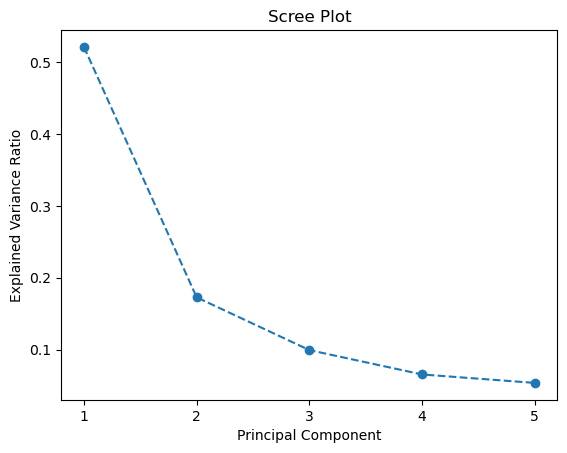

In [53]:
#Plot the explained variance against the principal component
plt.plot(range(1, len(explainedVarianceRatio) + 1), explainedVarianceRatio, marker='o', linestyle='--')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.xticks(range(1, len(explainedVarianceRatio) + 1)) #X-axis to increment in 1s
plt.show()

First three principal components have really significant variance. PC4 and PC5 also show significant variance but it starts to reduce drastically. Variance becomes insignificant after PC5. 


#### c)	Project the test set on the same PCA space produced by the training dataset (2 marks).



In [58]:
X_test_scores = pca.transform(X_test_scaled) #Perform PCA on test set
#Create a DataFrame of the first three principal components
test_scores_df = pd.DataFrame(X_test_scores[:,:3], columns=['PC1', 'PC2', 'PC3']) 


In [60]:
X_val_scores = pca.transform(X_val_scaled) #Perform PCA on validation set


#### d)	Plot two subplots in one figure: one for the training data in the PC1 and PC2 projection space and label the data in the picture according to its class; the other one for the test data in the same PCA space and label the data in the picture according to its class. Explain your findings in a markdown cell (6 marks)


In [63]:
import plotly.express as px #Imports express from plotly library for 3D plotting

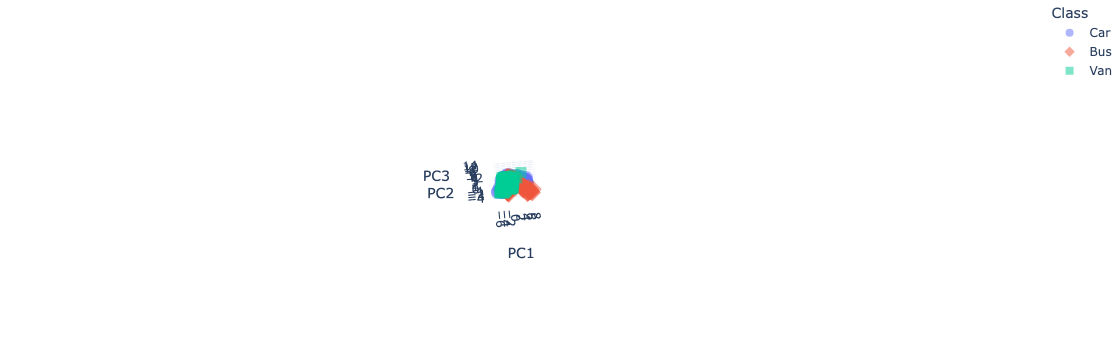

In [67]:
#Plot Training data in PC1, PC2 and PC3 projection space.
fig = px.scatter_3d(df_scores, x='PC1', y='PC2', z='PC3', color='Class', symbol='Class', opacity=0.5) 

#Enlarge plot for readability
fig.update_layout(margin=dict(l=0,r=0,b=0,t=0))

fig.show()

In [69]:
Y_label = [] #Decode 0,1,2 to Bus, Car, Van in order to concatenate testing scores with corresponding class name

for i in Y_test:
    if  i == 0:
        Y_label.append('Bus')
    elif i == 1:
        Y_label.append('Car')
    else:
        Y_label.append('Van')

Class = pd.DataFrame(Y_label, columns=['Class']) #Create DataFrame with decoded class labels

In [71]:
df_scores = pd.concat([test_scores_df, Class], axis=1) #Concatenate testing scores dataframe with class labels dataframe
df_scores

,PC1,PC2,PC3,Class
0,-1.852435,-2.373001,0.913499,Bus
1,0.421373,1.496140,0.295798,Bus
2,-4.042142,-3.465712,-0.319878,Van
3,-1.449931,1.294886,-0.170862,Bus
4,-2.082552,-3.114429,-0.078716,Bus
...,...,...,...,...
158,-2.384481,-3.345455,-0.385062,Bus
159,4.672457,-1.116832,-0.653305,Car
160,-3.885862,-1.635896,-1.003055,Van
161,-2.329116,-1.593373,-0.259151,Car


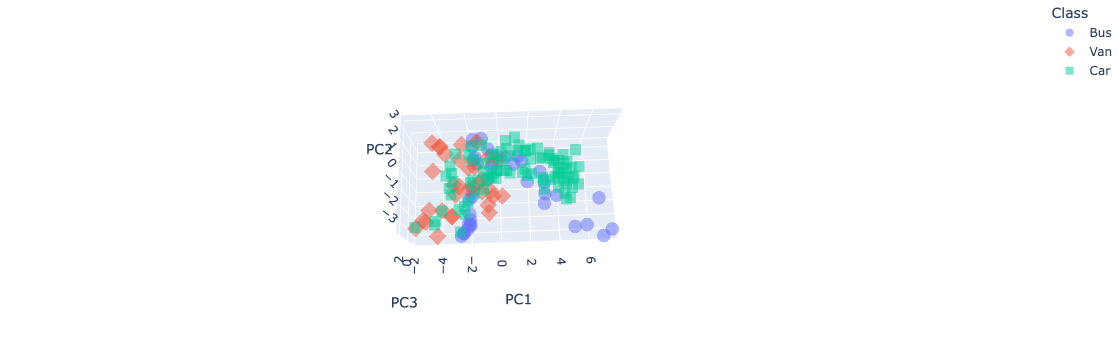

In [73]:
#Plot Testing data in PC1, PC2 and PC3 projection space.

fig = px.scatter_3d(df_scores, x='PC1', y='PC2', z='PC3', color='Class', symbol='Class', opacity=0.5)

#Enlarge plot for readability
fig.update_layout(margin=dict(l=0,r=0,b=0,t=0))

fig.show()

Looking at the 3D distribution, the three classes are highly clustered together and are oriented in a plane-like shape where its mostly flat in the Z-axis (PC3) with a range of -1  to 1. Most of the variability is in the X and Y axes (PC1 and PC2). But this makes sense since the first two principal components explain ~69% of the variance. 

There is a Van outlier at PC2 = 1.5 and PC3 = 2.6. This could be noise

For all three classes, PC3 remains mostly consistent at a range of -1 to 1. Van is mostly present at the negative values of PC1, and between the range of -3 and 3 for PC2. The Van class overlaps a lot with the Car class. The car class occupies the most space. Bus and Car overlap a lot. Van and Bus overlap slightly but are more seperable than with car. For PC1 values of 4 and higher, Bus is only present for negative PC3 and PC2 values and is the only class occupying this space. This shows that Bus holds a unique feature characterisitc in this region of space. Car has its own space for positive PC1 and PC2 values, Bus overlaps a little bit but not significantly, which means Car holds a unique feature characteristic in this region of space. The only unique space that Van has is for low negative PC1 values (-4 and lower). All three classses have their unique 3D space but they overlap a lot which shows they share many feautures.

There is an empty space for PC1 values ranging 0 - 3, where the PC2 is negative. This shows that none of the classes hold any feature characteristics that are unique to this 3D space.

Overall the structure shows that Bus dominates the bottom right of the space (Lokking from above at PC1xPC2), and the Van holds its only features on the LHS of the structure but shares these features with Car. The Van doesn't share many features with the Bus.



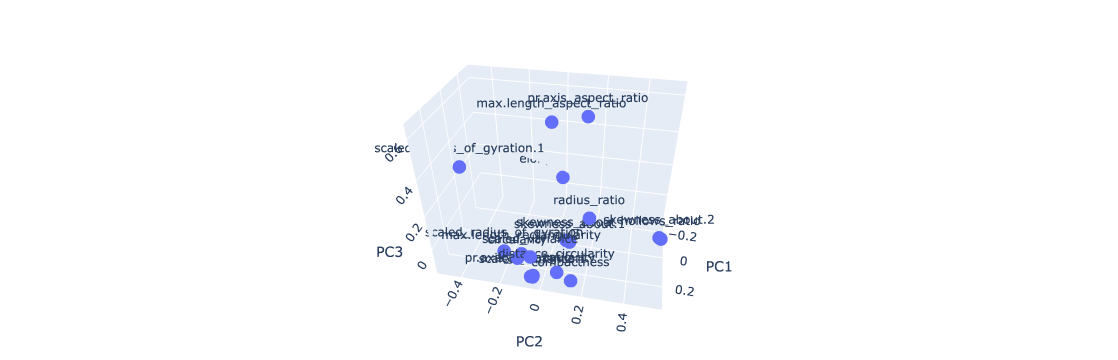

In [82]:
loadings_label = df_loadings.index #Feature names

#Plot loading data in PC1, PC2 and PC3 projection space, labelling the data as their correct feature name

fig = px.scatter_3d(df_loadings, x='PC1', y='PC2', z='PC3', text=loadings_label)

#Enlarge plot for readability
fig.update_layout(margin=dict(l=0,r=0,b=0,t=0))

fig.show()

Elongatedness, which has a PC1 of -0.3, contributes negatively to PC1. This means that as elongatedness increases, the PC1 decreases. 
Elongatedness is a key feature for Van, which seperates it from Bus and Car by pushing Van toward the negative end of PC1.


Scaled_radius_gyration.1, which has a PC2 of -0.49 contirbutes negatively to PC2. As it increases, the PC2 decreases significantly. This feature is also the only feature with a negative PC1 value, other than elongatedness. It has a PC1 of -0.00347, therefore Elongatedness is the primiary driver of Van. All three classes share space in the negative PC2 region, so all three classes have this feature in common. This feature is not responsible for class seperation.


Circularity, scaled_radius_of_gyration, scatter_ratio, scaled_variance.1 and pr.axis_rectangularity are the only features with negative PC2 and PC3 values. These features are the primiary drivers for the position of Bus in the PC1 > 4 region. Bus shares the features elongatedness and scaled_radius_of_gyration with car and van in the negative PC1 and PC2 regions which causes the classes to overlap in those areas.

compactness, circularity, distance_circularity, radius_ratio, scatter_ratio, pr.axis_rectangularity, scaled_variance and scaled_variance.1 all have high positive PC1 values therefore push the Cars to the positive end of PC1. elongatedness has strong negative PC1 value and so pushes car to the negative end of PC1.

Radius_ratio, pr.axis_aspect_Ratio and scaled_varaince have high PC2 values so push car to the positve end of PC2. Scaled_radius_of_gyration, scaled_radius_of_gyration.1 and circularity have high negative PC2 values and so push Cars to the negative end of PC2.




### Task 3: Do a classification using the Naïve Bayes Classification model. Explain your findings in a markdown cell (12 marks)
Train the model using the training set and report the performance on the validation set and test set including accuracy rate.


In [102]:
from sklearn.naive_bayes import GaussianNB #Imports GaussianNB from sklearn.naive_bayes module
from sklearn import metrics #Imports metrics module from sklearn
model = GaussianNB() #Initialize the Gaussian Naive Bayes model

In [104]:
model.fit(X_train_scores, Y_train) #Fit the model to the training data

GaussianNB()

In [106]:
Y_val_pred = model.predict(X_val_scores) #Predict target values for validation set
Y_test_pred = model.predict(X_test_scores) #Predict target values for testing set

In [108]:
#Validation set performance
accuracy = model.score(X_val_scores, Y_val)
report = metrics.classification_report(Y_val, Y_val_pred)
cm = metrics.confusion_matrix(Y_val, Y_val_pred)

print("VALIDATION SET:\n")
print("Accuracy: ", accuracy*100, "%")
print("\nClassification report: \n", report)
print("\nConfusion matrix: \n", cm)

VALIDATION SET:

Accuracy:  69.32515337423312 %

Classification report: 
               precision    recall  f1-score   support

           0       0.56      0.61      0.59        36
           1       0.76      0.88      0.82        91
           2       0.58      0.31      0.40        36

    accuracy                           0.69       163
   macro avg       0.63      0.60      0.60       163
weighted avg       0.68      0.69      0.67       163


Confusion matrix: 
 [[22  9  5]
 [ 8 80  3]
 [ 9 16 11]]


Bus:
22 correct classifications
9 misclassified as car
5 misclassified as van

Recall: 61% of Bus were classified correctly
Precision: 56% of all Bus predictions were actually true

Car:
80 correct classifications
8 misclassified as bus
3 misclassified as van

Recall: 88% of Car were classified correctly
Precision: 76% of all Car predictions were actually true

Van:
11 correct classifications
9 misclassified as bus
16 misclassified as car

Recall: 31% of Van were classified correctly
Precision: 58% of all Van predictions were actually true


In [115]:
#Testing set performance
accuracy = model.score(X_test_scores, Y_test)
report = metrics.classification_report(Y_test, Y_test_pred)
cm = metrics.confusion_matrix(Y_test, Y_test_pred)

print("TESTING DATASET:\n")
print("Accuracy: ", accuracy*100, "%")
print("\nClassification report: \n", report)
print("\nConfusion matrix: \n", cm)

TESTING DATASET:

Accuracy:  65.03067484662577 %

Classification report: 
               precision    recall  f1-score   support

           0       0.50      0.46      0.48        39
           1       0.72      0.89      0.80        91
           2       0.47      0.21      0.29        33

    accuracy                           0.65       163
   macro avg       0.56      0.52      0.52       163
weighted avg       0.62      0.65      0.62       163


Confusion matrix: 
 [[18 18  3]
 [ 5 81  5]
 [13 13  7]]


Bus:
18 correct classifications
18 misclassified as car
3 misclassified as van

Recall: 46% of Bus were classified correctly
Precision: 50% of all Bus predictions were actually true

Car:
81 correct classifications
5 misclassified as bus
5 misclassified as van

Recall: 89% of Car were classified correctly
Precision: 72% of all Car predictions were actually true

Van:
7 correct classifications
13 misclassified as bus
13 misclassified as car

Recall: 21% of Van were classified correctly
Precision: 47% of all Van predictions were actually true



Overall on the validation set the model performed slightly better at 69% accuracy than on the testing set at 65% accuracy. 

Also the validation set correctly classified 61% of the Bus's. Which is 15% more than the testing set which had a bus accuracy of 46%.

Both the validation and testing set had similar results for classifing cars, which is 88/89% respectively - very consistent.

For vans, the validation set correctly classified 31% of the Van's which is 10% more than the testing set which had a van accuracy of 21%.

Overall the Naive Bayes model worked better on the validation set. 

### Task 4: Do a classification using Linear Regression model (12 marks)

#### a) Train the model using the training set and report the intercept and coefficients. Explain your findings in a markdown cell (6 marks)


In [120]:
from sklearn.linear_model import LogisticRegression #Imports LogisticRegression from sklearn.linear_model module
from sklearn import metrics #Imports metrics module from sklearn

In [124]:
model = LogisticRegression() #Initialize the Logistic Regression Model
model.fit(X_train_scores, Y_train) #Fit the model using the training data


LogisticRegression()

In [126]:
print("Coefficients: \n", model.coef_) #Print the model coefficients
print("\nIntercepts: \n", model.intercept_) #Print the model intercept

Coefficients: 
 [[ 0.11526672 -0.34423948  0.20151845  0.28650906 -0.47759864]
 [ 0.24538     0.19084879 -0.54617957  0.2343713   0.26344878]
 [-0.36064672  0.15339069  0.34466112 -0.52088036  0.21414986]]

Intercepts: 
 [-0.08444036  0.62793865 -0.5434983 ]


Bus:
PC1, PC3 and PC4 slightly increase log-odds of bus prediction
PC2 and PC5 significantly reduces log-odds of bus prediction

Car:
PC1, PC2, PC4 and PC5 slightly increase log-odds of car prediction.
PC3 massively reduces log-odds of car predictions.

Van:
PC2 and PC5 slightly increase log-odds of van prediction
PC3 significantly inceases log-odds of van prediction
PC1 significantly decreases log-odds of van prediction
PC4 massively decreases log-odds of van prediction.

Summary of significant coefficients:
PC2 and PC5 significantly decreases the chance of predicting a bus.
PC3 significantly decreases the chance of predicting a car.
PC4 significantly decreases the chance of preciting a van.

When all Principal Components are 0, the baseline log-odds slightly disfavour predicting a bus, strongly favour predicting a car, and strongly disfavour predicting a van.

#### b) Report the performance on the validation set and test set by RMSE. Explain your findings in a markdown cell (6 marks)

In [134]:
from sklearn.metrics import mean_squared_error #Imports mean_squared_error function from sklearn.metrics module


Y_val_pred = model.predict(X_val_scores) #Predict the target values for validation data
Y_test_pred = model.predict(X_test_scores) #Predict the target values for testing data

In [136]:
#Validation set performance
accuracy = metrics.accuracy_score(Y_val, Y_val_pred)
mse = mean_squared_error(Y_val, Y_val_pred)
rmse = np.sqrt(mse)
report = metrics.classification_report(Y_val, Y_val_pred)
cm = metrics.confusion_matrix(Y_val, Y_val_pred)

print("VALIDATION SET:\nAccuracy: ", accuracy*100, "%")
print("RMSE: ", rmse)
print("Classification report: \n", report)
print("Confusion matrix: \n", cm)


VALIDATION SET:
Accuracy:  71.16564417177914 %
RMSE:  0.7389264306672555
Classification report: 
               precision    recall  f1-score   support

           0       0.59      0.61      0.60        36
           1       0.82      0.82      0.82        91
           2       0.56      0.53      0.54        36

    accuracy                           0.71       163
   macro avg       0.66      0.65      0.66       163
weighted avg       0.71      0.71      0.71       163

Confusion matrix: 
 [[22  7  7]
 [ 8 75  8]
 [ 7 10 19]]


Bus:
22 correct classifications
7 misclassified as car
7 misclassified as van

Recall: 61% of Bus were classified correctly
Precision: 59% of all Bus predictions were actually true

Car:
75 correct classifications
8 misclassified as bus
8 misclassified as van

Recall: 82% of Car were classified correctly
Precision: 82% of all Car predictions were actually true

Van:
19 correct classifications
7 misclassified as bus
10 misclassified as car

Recall: 53% of Van were classified correctly
Precision: 56% of all Van predictions were actually true



In [139]:
#Testing set performance
accuracy = metrics.accuracy_score(Y_test, Y_test_pred)
mse = mean_squared_error(Y_test, Y_test_pred)
rmse = np.sqrt(mse)
report = metrics.classification_report(Y_test, Y_test_pred)
cm = metrics.confusion_matrix(Y_test, Y_test_pred)

print("TESTING SET:\nAccuracy: ", accuracy*100, "%")
print("RMSE: ", rmse)
print("Classification report: \n", report)
print("Confusion matrix: \n", cm)

TESTING SET:
Accuracy:  61.34969325153374 %
RMSE:  0.8139881369630422
Classification report: 
               precision    recall  f1-score   support

           0       0.37      0.33      0.35        39
           1       0.73      0.76      0.74        91
           2       0.55      0.55      0.55        33

    accuracy                           0.61       163
   macro avg       0.55      0.55      0.55       163
weighted avg       0.60      0.61      0.61       163

Confusion matrix: 
 [[13 21  5]
 [12 69 10]
 [10  5 18]]


Bus:
13 correct classifications
21 misclassified as car
5 misclassified as van

Recall: 33% of Bus were classified correctly
Precision: 37% of all Bus predictions were actually true

Car:
69 correct classifications
12 misclassified as bus
10 misclassified as van

Recall: 76% of Car were classified correctly
Precision: 73% of all Car predictions were actually true

Van:
18 correct classifications
10 misclassified as bus
5 misclassified as car

Recall: 55% of Van were classified correctly
Precision: 55% of all Van predictions were actually true



Overall on the validation set the model performed better at 71% accuracy than on the testing set at 61% accuracy. The testing set RMSE, 0.81, is higher than the validation set RMSE, 0.73, which shows that the model's predictions were better on the validation set. This could indicate slight overfitting.

Also the validation set correctly classified 61% of the Bus's which is massively better than the testing set at a bus accuracy of 33%. (28% difference)

The validation set correctly classified 82% of the Car's which is better than the testing set at a car accuracy of 76% (6% difference)

For vans, both the validation and testing set performed consistently with a van accuracy of 53/55% respectively - very consistent.

Overall the Logistic Regression Model performed better on the validation set. The model struggled to correctly classify Bus's on the testing set which is where the major differences in performance were made.

### Task 5: Summarize your findings, write your conclusions using critical thinking (no more than 100 words) (6 marks).

The Naive Bayes and Logistic Regresison models performed better on the validation sets (69% and 71% accuracy) than on the test sets (65% and 61% accuracy). The Bus class has 61% accuracy on the validation set and 33% on the test set, showing overfitting. 

The key driver for the Van class was Elongatedness.
Features with negative PC2 and PC3 values such as Circularity and Scaled Radius of Gyration were the primary drivers for Bus in the PC1 > 4 region.
Car was driven by features with high (+ or -) PC1 and PC2 values, such as compactness, circularity, etc.

The classes overlap significantly due to shared features such as elongatedness and scaled radius of gyration. This caused a lot of missclassifications. Car was classified well.